# Séance 3 (Notebook B) : Arbres binaires et BST

**Enseignant :** Jean Delpech

**Cours :** Algorithmie et développement dans l'ingénierie des données

**Classe :** M1 Data

**Année scolaire :** 2025/2026

**Dernière mise à jour :** juin 2026

## Objectifs

- Comprendre les arbres binaires comme structures récursives et maîtriser leur terminologie
- Connaître les quatre types de parcours et savoir choisir lequel utiliser
- Comprendre la propriété BST, son intérêt, et sa limite principale : la dégénérescence
- Établir le lien entre BST, index B-tree PostgreSQL et arbre de décision CART

## Plan

| # | Partie |
|---|---|
| 1 | Terminologie et structure des arbres binaires |
| 2 | Les quatre parcours |
| 3 | Arbre binaire de recherche (BST) |
| 4 | Dégénérescence et arbres équilibrés |
| 5 | Liens avec l'ingénierie de données et le ML |

> **Notebooks complémentaires de cette séance**
> - **Notebook A** : Listes chaînées, Piles, Files, Récursion
> - **Notebook C** : Tas binaire (Heap) et files de priorité


# PARTIE 1 : Terminologie et structure des arbres binaires

## 1.1 Qu'est-ce qu'un arbre ?

Un **arbre** est une structure de données récursive : un arbre est soit vide, soit un **nœud racine** relié à un ensemble de **sous-arbres** (ses enfants), qui sont eux-mêmes des arbres.

Un **arbre binaire** est un arbre où chaque nœud a **au plus deux enfants**, appelés enfant gauche et enfant droit.

```
             ┌───┐
             │ A │  ← racine
             └─┬─┘
       ┌───────┴───────┐
     ┌─┴─┐           ┌─┴─┐
     │ B │           │ C │  ← nœuds internes
     └─┬─┘           └─┬─┘
   ┌───┴───┐           └───┐
 ┌─┴─┐   ┌─┴─┐           ┌─┴─┐
 │ D │   │ E │           │ F │  ← feuilles
 └───┘   └───┘           └───┘
```

On peut définir le nœud d’un arbre bianaire comme un élément contenant trois champs :
- sa valeur
- un poineur (référence) vers le sous-arbre gauche
- un pointeur (réféence) vers le sous-arbre droit

> On voit ici  ce qui distingue un arbre d’une liste chaînée : un élément d’une liste chaînée (simple) contient *deux* champs, sa valeur et un pointeur vers l’élément suivant, là où un nœud en contient trois.
>
> Il y a une autre différence : les deux références d’un nœud pointent vers un niveua *inférieur* : il existe une relation *hiérarchique* dans cette structure. Cela implique :
> - qu’il y a un seul chemin entre la racine et n’importe quel nœud
> - qu’un nœud ne pointe jamais vers un nœud du même niveau ou « vers l’arrière/le haut »
> - qu’il ne peut pas y avoir de cycle
> - qu’il n‘y a *qu’un seul parent* par nœud
>
> Une liste doublement chaînée, dont les éléments possèdent deux références aussi, est elle une structure linéaire dont les deux références de chaque élément pointent vers le même niveau.
> En fait on verra plus tard que certains types d’arbres justement peuvent *dégénérer* vers une structure linéaire comme une lsite chaînée en perdant  ce qui fait leur intérêt : la structure hiérarchique.

## 1.2 Vocabulaire fondamental

| Terme | Définition |
|---|---|
| **Racine** | Nœud sans parent / point d'entrée de l'arbre |
| **Feuille** | Nœud sans enfant |
| **Nœud interne** | Nœud avec au moins un enfant |
| **Hauteur d'un nœud** | Longueur du plus long chemin vers une feuille descendante |
| **Profondeur d'un nœud** | Nombre d'arêtes entre ce nœud et la racine |
| **Hauteur de l'arbre** | Hauteur de la racine / mesure globale de la taille de l'arbre |
| **Sous-arbre** | Un nœud et tous ses descendants : c'est lui-même un arbre |

> **Hauteur vs profondeur :** la profondeur se mesure depuis la racine vers le bas jusqu’au nœud considéré (combien de niveaux au-dessus de moi ?), la hauteur se mesure depuis le nœud considéré jusuq’au bas/dernier nœud (combien de niveaux sous moi ?). La racine a une profondeur de 0 et une hauteur égale à la hauteur de l'arbre.

## 1.3 Propriétés importantes

Un arbre binaire de hauteur h contient **au maximum 2^(h+1) - 1 nœuds** (arbre complet, tous les niveaux remplis).

Inversement, un arbre binaire contenant n nœuds a une hauteur **au minimum de ⌊log₂(n)⌋**.

C'est cette propriété logarithmique qui rend les arbres binaires intéressants pour la recherche : sur un arbre équilibré, trouver un élément parmi n ne nécessite que log₂(n) comparaisons.

> Un arbre binaire est dit **équilibré** lorsque la différence de hauteur entre le sous-arbre gauche et le sous-arbre droit est faible pour **chaque nœud** de l'arbre. On verra plus loin comment on juge que la différence est *faible* ou non.


In [1]:
from __future__ import annotations
from typing import Optional


class BinaryNode:
    """Nœud d'un arbre binaire générique."""

    def __init__(self, value):
        self.value = value
        self.left:  Optional[BinaryNode] = None
        self.right: Optional[BinaryNode] = None

    def __repr__(self):
        return f"BinaryNode({self.value!r})"

    def is_leaf(self) -> bool:
        """Retourne True si le nœud est une feuille."""
        return self.left is None and self.right is None

    def height(self) -> int:
        """Hauteur du nœud - récursif. O(n)."""
        left_h  = self.left.height()  if self.left  else -1
        right_h = self.right.height() if self.right else -1
        return 1 + max(left_h, right_h)


# ── Construction manuelle de l'arbre illustré ci-dessus ────────────
root    = BinaryNode('A')
root.left           = BinaryNode('B')
root.right          = BinaryNode('C')
root.left.left      = BinaryNode('D')
root.left.right     = BinaryNode('E')
root.right.right    = BinaryNode('F')

print(f"Racine         : {root.value}")
print(f"Hauteur        : {root.height()}")
print(f"B est une feuille ? {root.left.is_leaf()}")
print(f"D est une feuille ? {root.left.left.is_leaf()}")


Racine         : A
Hauteur        : 2
B est une feuille ? False
D est une feuille ? True


Lisez attentiveemnt le code ci-dessus, et notamment comment un arbre binaire est défini mauellement. Efforcez-vous de faire le lien (au besoin, faites un dessin) avec les définitions données en début de section.

# PARTIE 2 : Les quatre parcours

## 2.1 Pourquoi plusieurs parcours ?

Parcourir un arbre signifie visiter chaque nœud exactement une fois. Contrairement à une liste où l'ordre est imposé, un arbre offre plusieurs ordres de visite selon ce qu'on cherche à faire.

Il existe quatre parcours classiques, regroupés en deux familles :

| Famille | Parcours | Ordre de visite |
|---|---|---|
| **DFS** (en profondeur) | Pré-ordre | Racine → Gauche → Droite |
| **DFS** (en profondeur) | In-ordre | Gauche → Racine → Droite |
| **DFS** (en profondeur) | Post-ordre | Gauche → Droite → Racine |
| **BFS** (en largeur) | Par niveaux | Niveau 0 → Niveau 1 → ... |


![Schema BFS](./Images/BFSbinaire.png)

Dans le parcours dit en largeur (*Breadth First Search* – BFS), on va explorer l’arbre à partir d’un nœeud en se déplaçant, « de niveau en niveau », en descendant le niveau inférieur après avoir exploré les deux branches d’un niveau donné. Sur le schéma ci-dessus par exemple, l’exploration a consisté d’abord à emprunter les deux branches rouges, puis les bleues et oranges, etc.

![Schema DFS](./Images/DFSbinaire.png)

Pour le parcours dit en profondeur (*Depth First Search* – DFS), on va explorer l’abre en descendant aussi loin que possible dans un sous-arbre avant de revenir en arrière (backtracking) pour explorer les autres sous-arbres. On passe directement d’un niveau à l’autre jusqu’à avoir parcouru toute la hauteur de l’arbre. Sur le schéma ci-dessus par exemple, emprunter les branche rouge, puis bleue, puis jaune, puis verte… pour explorer les nœuds correspondants.

Dans le cas du DFS on voit qu’on a diffrentes possibilités : quand on « descend » est-ce qu’on commence par la gauche ou la droite ? On voit également qu’on pourrait « remonter » l’arbre depuis les feuilles. Dans quel ordre visite-t-on les nœuds ? 

Plusieurs considérations sont concurrentes ici :

- la convention : on choisit généralement d'explorer le sous-arbre gauche avant le sous-arbre droit
- à quel moment visite-t-on la racine ou un parent par rapport à ses deux sous-arbres ? Dans quelle ordre ? Avant ? Après ? Entre les deux ?

Ce dernier choix permet de définir plusieurs types de DFS, que nosu allons détailler à la section suivante.

## 2.2 Les trois parcours DFS

Les parcours DFS sont naturellement récursifs : on descend (ou on remonte) le plus profondément possible avant de revenir.

**Pré-ordre** : on visite le nœud parent *avant* ses enfants. Utile pour copier ou sérialiser un arbre.

> Sérialiser un arbre signifie le convertir en une séquence linéaire (une chaîne de caractères, un fichier JSON, un flux d'octets) pour le stocker ou le transmettre, puis pouvoir le reconstruire à l'identique à partir de cette séquence.
Le pré-ordre est adapté à cet usage car en commençant par la racine, on produit une séquence dans laquelle la structure parentale précède toujours les enfants, ce qui permet de reconstruire l'arbre nœud par nœud dans le même ordre sans ambiguïté
(la racine doit être connue avant ses enfants).

C’est plus clair avec un schéma :

![Schéma DFS pré-ordre](./Images/DFSpre-ordre.png)


**In-ordre** : on visite le nœud parent *entre* ses deux enfants. Soit les nœud A B C (A étant le nœud racine) on va visiter le sous-arbre dont B est la racine, puis le nœud racine (A) et finir avec l’autre sous-arbre dont C est la racine. A (la racine) aura été visité *entre* les deux sous-arbres (dont B et C sont les racines).

Un schéma sera plus parlant : 

![Schéma DFS in-ordre](./Images/DFSin-ordre.png)

> Propriété clé qu’on verra plus tard : sur un Binary Search Tree (BST, l'in-ordre produit les valeurs **dans l'ordre croissant**. C'est le parcours fondamental pour les BST). On y reviendra, mais c’est pour que vous l’ayez bien en tête.

**Post-ordre** : on visite le nœud parent *après* ses enfants. Utile pour supprimer un arbre (on libère les enfants avant le parent) ou calculer une expression arithmétique.

![Schéma DFS post-ordre](./Images/DFSpost-ordre.png)


#### Exercice
Soit l’arbre ci-dessous, ordonnez les nœuds selon le type de DFS (pour info, c’est un BST, essayez de retrouver la propriété énoncée plus haut). Pour vous aider, on vous donne déjà le pré-ordre :



```
        ┌───┐
        │ 4 │
        └─┬─┘
    ┌─────┴─────┐
  ┌─┴─┐       ┌─┴─┐
  │ 2 │       │ 6 │
  └─┬─┘       └─┬─┘
 ┌──┴──┐     ┌──┴──┐
┌┴┐   ┌┴┐   ┌┴┐   ┌┴┐
│1│   │3│   │5│   │7│
└─┘   └─┘   └─┘   └─┘

Répondez en éditant cette cellule
```

## 2.3 Le parcours BFS (par niveaux)

Le BFS visite les nœuds niveau par niveau, de gauche à droite. Il utilise une **file FIFO** (et non la récursion) : on « enfile » la racine, puis à chaque itération on « défile » un nœud et on « enfile » ses enfants.

Utile pour trouver le chemin le plus court dans un arbre, ou afficher l'arbre niveau par niveau.

## 2.4 Implémentation

BFS et DFS reposent sur deux mécanismes élémentaires bien distincts : la file pour l’un, la récursion pour l’autre (ou une pile LIFO : en réalité la récursion utilise la pile du système). Cela va avoir des implications en matière de coût/complexité. Dans les deux cas les nœuds ne sont visités qu’une fois, donc la complexité en temps est identique dans les deux cas, O(n). Mais dans certaines situations cela peut avoir des conséquence quant à la mémoire, selon les caractéristiques de l’arbre : arbre équilibré ou non, large ou pas, l’arbre est-il profond, dégénéré (affaiblissement de la structure hiérarchique), la recherche reste-t-elle proche de la racine ou plutôt proche des feuilles ? Tout cela peut avoir un impact, nous y reviendront.

D’abord voyons sur quelles opérations reposent ces algorithmes BFS et DFS.

### BFS

Le parcours BFS procède niveau par niveau : on met chaque nœud d’un niveau dans une file, puis on les « dé-file », on récupère leur valeur et on place chaque enfant de ces nœuds dans la file, et ainsi de suit. On explore ainsi chaque niveau l’un après l’autre.
On dispose d’une liste de valeurs des nœuds parcourus (`result`). La fonction `bfs()` va parcourir l’arbre niveau par niveau :

1. `bfs()` reçoit un nœud racine en argument
2. On met le nœud racine dans une file
3. Tant que la file n’est pas vide :
    1. on « dé-file » le premier nœud
    2. on ajoute la valeur du nœud courant à la liste `result`
    3. s’il y a un nœud enfant à gauche : on l’ajoute à la file
    4. s’il y a un nœud enfant à droite : on l’ajoute à la file
4. On retourne la liste de valeurs/résultats quand il n‘y a plus rien dans la file (sortie de boucle)


```python
def bfs(root: Optional[BinaryNode]) -> list:
    """Parcours par niveaux. Utilise une file FIFO."""
    if root is None:
        return []
    result = []
    queue  = deque([root])
    while queue:
        node = queue.popleft()          # défiler
        result.append(node.value)       # visiter
        if node.left:  queue.append(node.left)   # enfiler les enfants
        if node.right: queue.append(node.right)
    return result
```

### DFS

Le parcours DFS repose sur la récursion, qui va nous permettre de créer assez facilement les différentes variantes du DFS. Voyons comment elle se présente :

#### Pre-order
On dispose d’une liste de valeurs des nœuds parcourus (`result`). La fonction `preorder()` qui explore l’arbre dans l’ordre racine → gauche → droite :

1. Reçoit un nœud en argument
2. Si le nœud est vide, alors on retourne la liste de valeur aggrégée jusqu’ici (on est arrivé au bout, pas de sous-arbre)
3. Sinon :
    1. on ajoute la valeur du nœud courant à la liste
    2. et on va explorer (appliquer `preorder`) le nœud racine du sous-arbre gauche,
    3. puis le nœud racine du sous-arbre droit
4. On retourne la liste de valeurs/résultats

```python
def preorder(node: Optional[BinaryNode], result: list = None) -> list:
    """Pré-ordre : racine → gauche → droite."""
    if result is None:
        result = []
    if node is None:
        return result
    result.append(node.value)      # 1. visiter la racine
    preorder(node.left,  result)   # 2. sous-arbre gauche
    preorder(node.right, result)   # 3. sous-arbre droit
    return result
```

#### in-order

On procède de même, avec la fonction in-order, mais cette fois-ci on applique la séquence dans un ordre un peu diffrent (gauche → racine → droite) :

1. Reçoit un nœud en argument
2. Si le nœud est vide, alors on retourne la liste de valeur aggrégée jusqu’ici (on est arrivé au bout)
3. Sinon :
    1. On explore (appliquer `inorder`) le nœud racine du sous-arbre gauche,
    2. On ajoute la valeur du nœud courant à la liste
    3. puis on explore le nœud racine du sous-arbre droit
4. On retourne la liste de valeurs/résultats

```python
def inorder(node: Optional[BinaryNode], result: list = None) -> list:
    """In-ordre : gauche → racine → droite. Donne l'ordre croissant sur un BST."""
    if result is None:
        result = []
    if node is None:
        return result
    inorder(node.left,  result)    # 1. sous-arbre gauche
    result.append(node.value)      # 2. visiter la racine
    inorder(node.right, result)    # 3. sous-arbre droit
    return result
```

#### post-order

Enfin la séquence gauche → droite → racine pour la focntion `postorder` :

1. Reçoit un nœud en argument
2. Si le nœud est vide, alors on retourne la liste de valeur aggrégée jusqu’ici (on est arrivé au bout)
3. Sinon :
    1. on explore (appliquer `postorder`) le nœud racine du sous-arbre gauche,
    2. puis on explore le nœud racine du sous-arbre droit,
    3. enfin ajoute la valeur du nœud courant à la liste
4. On retourne la liste de valeurs/résultats

```python
def postorder(node: Optional[BinaryNode], result: list = None) -> list:
    """Post-ordre : gauche → droite → racine."""
    if result is None:
        result = []
    if node is None:
        return result
    postorder(node.left,  result)  # 1. sous-arbre gauche
    postorder(node.right, result)  # 2. sous-arbre droit
    result.append(node.value)      # 3. visiter la racine
    return result
```

### Le code

In [2]:
from collections import deque
from typing import Optional


# ── Parcours DFS (récursifs) ───────────────────────────────────────

def preorder(node: Optional[BinaryNode], result: list = None) -> list:
    """Pré-ordre : racine → gauche → droite."""
    if result is None:
        result = []
    if node is None:
        return result
    result.append(node.value)      # 1. visiter la racine
    preorder(node.left,  result)   # 2. sous-arbre gauche
    preorder(node.right, result)   # 3. sous-arbre droit
    return result


def inorder(node: Optional[BinaryNode], result: list = None) -> list:
    """In-ordre : gauche → racine → droite. Donne l'ordre croissant sur un BST."""
    if result is None:
        result = []
    if node is None:
        return result
    inorder(node.left,  result)    # 1. sous-arbre gauche
    result.append(node.value)      # 2. visiter la racine
    inorder(node.right, result)    # 3. sous-arbre droit
    return result


def postorder(node: Optional[BinaryNode], result: list = None) -> list:
    """Post-ordre : gauche → droite → racine."""
    if result is None:
        result = []
    if node is None:
        return result
    postorder(node.left,  result)  # 1. sous-arbre gauche
    postorder(node.right, result)  # 2. sous-arbre droit
    result.append(node.value)      # 3. visiter la racine
    return result


# ── Parcours BFS (itératif, file FIFO) ────────────────────────────

def bfs(root: Optional[BinaryNode]) -> list:
    """Parcours par niveaux. Utilise une file FIFO."""
    if root is None:
        return []
    result = []
    queue  = deque([root])
    while queue:
        node = queue.popleft()          # défiler
        result.append(node.value)       # visiter
        if node.left:  queue.append(node.left)   # enfiler les enfants
        if node.right: queue.append(node.right)
    return result


# ── Démonstration sur l'arbre de l'exemple ────────────────────────
print(f"Pré-ordre  : {preorder(root)}")
print(f"In-ordre   : {inorder(root)}")
print(f"Post-ordre : {postorder(root)}")
print(f"BFS        : {bfs(root)}")


Pré-ordre  : ['A', 'B', 'D', 'E', 'C', 'F']
In-ordre   : ['D', 'B', 'E', 'A', 'C', 'F']
Post-ordre : ['D', 'E', 'B', 'F', 'C', 'A']
BFS        : ['A', 'B', 'C', 'D', 'E', 'F']


# PARTIE 3 : Arbre Binaire de Recherche (BST)

## 3.1 La propriété BST

Un **arbre binaire de recherche** (*Binary Search Tree*, BST) est un arbre binaire qui respecte une règle stricte sur chaque nœud :

> Pour tout nœud N :
> - toutes les valeurs du **sous-arbre gauche** sont **strictement inférieures** à N
> - toutes les valeurs du **sous-arbre droit** sont **supérieures ou égales** à N

Cette propriété est **récursive** : elle doit être vérifiée pour chaque nœud de l'arbre, pas seulement la racine.

```
         ┌───┐
         │ 5 │
         └─┬─┘
     ┌─────┴─────┐
   ┌─┴─┐       ┌─┴─┐
   │ 3 │       │ 8 │
   └─┬─┘       └─┬─┘
  ┌──┴──┐        └──┐
 ┌┴┐   ┌┴┐        ┌─┴─┐
 │1│   │4│        │ 9 │
 └─┘   └─┘        └───┘
```

Vérification : 
- 3 < 5 et 1 < 5 et 4 < 5 : ok
- 8 >= 5 : ok
- 9 > 5 et 9 > 8 : ok
- 1 < 3 et 4 > 3 :ok…

Un parcours in-ordre donne 1 3 4 5 8 9, on obtient un ordre croissant ! Cette dernière propriété (non démontrée ici) est très utile :

## 3.2 BST et complexité de la recherche

La propriété BST permet de **rechercher en O(log n)** sur un arbre équilibré : à chaque nœud, on sait immédiatement si la valeur cherchée est à gauche ou à droite, éliminant la moitié de l'arbre restant à chaque étape. C'est exactement le principe de la recherche dichotomique, mais sur une structure en arbre plutôt que sur un tableau trié.

| Opération | Complexité (équilibré) | Complexité (dégénéré) |
|---|---|---|
| Recherche | O(log n) | O(n) |
| Insertion | O(log n) | O(n) |
| Suppression | O(log n) | O(n) |
| In-ordre (tri) | O(n) | O(n) |

## 3.3 Implémentation

L’implémentation d’un BST n’est pas triviale. Il y a quelques points importants, d’autant que le code suivant suit les pratiques montrées à la première séance (clean code).

Vous pouvez bien sûr jeter un œil au code sous cette section pour bien situer les explications.

### La séparation BST / BSTNode

L'implémentation repose sur deux classes distinctes, comme pour la liste chaînée : 
- `BSTNode` ne porte que les données (valeur + deux références),
- `BST` encapsule la logique et maintient le point d'entrée root. L'utilisateur n'interagit qu'avec BST : il n'a jamais à manipuler les nœuds directement.

### Le doublement des méthodes : méthodes publiques et méthodes récursives

Le point qui vous marquera sûrement le plus sur la forme est que nous avons écrit chaque fonction deux fois semble-t-il :
`insert` et `_insert`, `search` et `_search`, `delete` et `_delete`.

C’est une convention Python que d’écrire une méthode à laquelle l’utilisateur n’est pas sensé utiliser (privée) en dehors de la classe. *A priori* un développeur qui utilise notre classe BST ne devrait appeler que les version sans underscore `_`. 

Pourquoi chaque opération est en réalité deux fonctions ? C'est une convention courante en Python pour les structures récursives, qui répond à un problème concret.
La méthode récursive a besoin d'un paramètre `node`(le nœud courant) qui change à chaque appel. Mais l'utilisateur ne devrait pas avoir à passer ce paramètre : il veut juste écrire `bst.search(4)`, pas `bst.search(bst.root, 4)`.

On sépare donc les *responsabilités* (vous vous souvenez de cette notion vue en 1ère séance ?) :

La méthode publique (`search`) fournit *l'interface* (idem, notion déjà vue) propre, initialise l'appel avec `self.root`, et est la seule visible de l'extérieur.
La méthode privée (`_search`, le `_` signalant par convention qu'elle est interne) porte la logique récursive et reçoit le nœud courant en paramètre.

Voyons ces méthodes plus en détail.

#### `insert` et `_insert`
`_insert` (la version récursive) retourne toujours un nœud. Plutôt que de modifier les pointeurs directement, chaque appel récursif retourne le nœud à placer à cet endroit de l'arbre. Quand on atteint `None` (la position d'insertion), on retourne un nouveau nœud. Sinon on retourne le nœud courant après avoir récursivement mis à jour son enfant gauche ou droit.

Imaginons qu’on a le BST suivant et qu’on cherche à placer la valeur `4` :
```
    5
   / \
  3   8
```

1. `bst.insert(4)` appelle `self._insert(self.root, 4)` : on part de la racine avec la valeur 4 à placer.
2. Niveau 1 : nœud 5. On teste 4 < 5, donc la place de 4 est quelque part dans le sous-arbre gauche. On appelle récursivement `_insert(nœud_3, 4)` et on attend ce qu'il retourne pour le réaffecter à `node.left`.
2. Niveau 2 : nœud 3. On teste 4 > 3, donc la place de 4 est dans le sous-arbre droit de 3. On appelle `_insert(None, 4)` et l'enfant droit de 3 est vide.
3. Niveau 3 : `None`.  On a trouvé la position. On crée `BSTNode(4)` et on le retourne.

Maintenant la pile d'appels se déroule en remontant :

1. `_insert(None, 4)` retourne `BSTNode(4)`
2. `_insert(nœud_3, 4)` reçoit ce retour, l'affecte à `nœud_3.right`, et retourne `nœud_3`
3. `_insert(nœud_5, 4)` reçoit `nœud_3`, l'affecte à `nœud_5.left`, et retourne `nœud_5`
4. `insert` affecte le résultat final à `self.root`

```
    5
   / \
  3   8
   \
    4   ← inséré ici
```

#### `search` et `_search`
La logique exploite directement la propriété BST à chaque nœud : si la valeur cherchée est inférieure, elle ne peut être que dans le sous-arbre gauche, inutile d'explorer le droit. C'est ce qui donne O(log n) sur un arbre équilibré : à chaque niveau on élimine la moitié de l'arbre restant.
Deux cas d'arrêt : 
- `node is None` (valeur absente) ou `node.value == value` (trouvé). Dans les deux cas on retourne `node None` ou le nœud trouvé, ce qui permet à l'appelant de distinguer les deux situations.

#### `delete` et `_delete`

La suppression est l'opération la plus délicate car supprimer un nœud ne doit pas rompre la propriété BST. Trois situations selon le nœud à supprimer :
- Cas 1 : pas d'enfant gauche. On retourne simplement `node.right` (qui peut être `None`). Le nœud disparaît, son éventuel enfant droit prend sa place.
- Cas 2 : pas d'enfant droit : symétrique, on retourne `node.left`.
- Cas 3 : deux enfants. C'est le cas non trivial. On ne peut pas simplement supprimer le nœud, il faut le remplacer par une valeur qui maintient la propriété BST. C’est là que les ennuis arrivent.
  Le candidat naturel est le successeur in-ordre : le plus petit nœud du sous-arbre droit, c'est-à-dire le nœud le plus à gauche dans le sous-arbre droit. Il est garanti supérieur à tout le sous-arbre gauche et inférieur à tout le reste du sous-arbre droit. On copie sa valeur dans le nœud courant, puis on le supprime récursivement du sous-arbre droit, ce qui ramène au cas 1 ou 2.

C’est compliqué ! Prenez le temps de relire cette implémentation au calme.

In [5]:
from __future__ import annotations
from typing import Optional


class BSTNode:
    """Nœud d'un arbre binaire de recherche."""

    def __init__(self, value):
        self.value = value
        self.left:  Optional[BSTNode] = None
        self.right: Optional[BSTNode] = None

    def __repr__(self):
        return f"BSTNode({self.value!r})"


class BST:
    """Arbre binaire de recherche."""

    def __init__(self):
        self.root: Optional[BSTNode] = None

    # ── Insertion ─────────────────────────────────────────────────

    def insert(self, value) -> None:
        """Insère une valeur. O(h) où h est la hauteur de l'arbre."""
        self.root = self._insert(self.root, value)

    def _insert(self, node: Optional[BSTNode], value) -> BSTNode:
        if node is None:
            return BSTNode(value)          # position trouvée
        if value < node.value:
            node.left  = self._insert(node.left,  value)
        else:
            node.right = self._insert(node.right, value)
        return node

    # ── Recherche ─────────────────────────────────────────────────

    def search(self, value) -> Optional[BSTNode]:
        """Recherche une valeur. Retourne le nœud ou None. O(h)."""
        return self._search(self.root, value)

    def _search(self, node: Optional[BSTNode], value) -> Optional[BSTNode]:
        if node is None or node.value == value:
            return node
        if value < node.value:
            return self._search(node.left,  value)
        return self._search(node.right, value)

    # ── Suppression ───────────────────────────────────────────────

    def delete(self, value) -> None:
        """Supprime une valeur. O(h)."""
        self.root = self._delete(self.root, value)

    def _delete(self, node: Optional[BSTNode], value) -> Optional[BSTNode]:
        if node is None:
            return None
        if value < node.value:
            node.left  = self._delete(node.left,  value)
        elif value > node.value:
            node.right = self._delete(node.right, value)
        else:
            # Nœud trouvé - trois cas :
            if node.left is None:          # cas 1 : pas d'enfant gauche
                return node.right
            if node.right is None:         # cas 2 : pas d'enfant droit
                return node.left
            # cas 3 : deux enfants → remplacer par le successeur in-ordre
            # (le plus petit nœud du sous-arbre droit)
            successor = self._min_node(node.right)
            node.value = successor.value
            node.right = self._delete(node.right, successor.value)
        return node

    def _min_node(self, node: BSTNode) -> BSTNode:
        """Retourne le nœud avec la valeur minimale (le plus à gauche)."""
        while node.left:
            node = node.left
        return node

    # ── Utilitaires ───────────────────────────────────────────────

    def inorder(self) -> list:
        """Retourne les valeurs dans l'ordre croissant."""
        result = []
        self._inorder(self.root, result)
        return result

    def _inorder(self, node, result):
        if node:
            self._inorder(node.left,  result)
            result.append(node.value)
            self._inorder(node.right, result)

    def height(self) -> int:
        """Hauteur de l'arbre. O(n)."""
        return self._height(self.root)

    def _height(self, node) -> int:
        if node is None:
            return -1
        return 1 + max(self._height(node.left), self._height(node.right))


# ── Démonstration ─────────────────────────────────────────────────
bst = BST()
for v in [5, 3, 8, 1, 4, 9]:
    bst.insert(v)

print(f"In-ordre (doit être trié) : {bst.inorder()}")
print(f"Hauteur                   : {bst.height()}")
print(f"Recherche 4               : {bst.search(4)}")
print(f"Recherche 7               : {bst.search(7)}")

bst.delete(3)
print(f"Après suppression de 3    : {bst.inorder()}")


In-ordre (doit être trié) : [1, 3, 4, 5, 8, 9]
Hauteur                   : 2
Recherche 4               : BSTNode(4)
Recherche 7               : None
Après suppression de 3    : [1, 4, 5, 8, 9]


## 3.3 Exercice : Valider la propriété BST

Étant donné un arbre binaire quelconque, écrire une fonction `is_valid_bst(node)` qui vérifie que la propriété BST est bien respectée sur l'ensemble de l'arbre.

**Attention au piège classique :** vérifier uniquement que `node.left.value < node.value < node.right.value` ne suffit pas. Il faut vérifier que **tous** les nœuds du sous-arbre gauche sont inférieurs, pas seulement l'enfant direct.

```
       ┌───┐
       │ 5 │
       └─┬─┘
   ┌─────┴─────┐
 ┌─┴─┐       ┌─┴─┐
 │ 3 │       │ 7 │     ← 7 > 5 c’est bon localement
 └─┬─┘       └───┘
   └──┐
    ┌─┴─┐
    │ 6 │              ← 6 > 5 ok, mais 6 est dans le sous-arbre GAUCHE, c’est donc invalide !
    └───┘
```

> Implémenter `is_valid_bst(node, min_val, max_val)` en propageant des bornes min/max à chaque appel récursif.  
> Complexité attendue : O(n), chaque nœud visité une seule fois.
>
> Le code est assez court, mais pas forcément évident. Pensez à lister les différents cas de figure auxquels vous pouvez faire face en parcourant un arbre binaire.


In [ ]:
def is_valid_bst(node: Optional[BSTNode],
                 min_val: float = float('-inf'),
                 max_val: float = float('inf')) -> bool:
    """
    Vérifie récursivement que l'arbre respecte la propriété BST.
    min_val et max_val définissent l'intervalle valide pour ce nœud.
    """
    # TODO
    pass


# ── Tests ─────────────────────────────────────────────────────────

# BST valide
valid = BST()
for v in [5, 3, 7, 1, 4]:
    valid.insert(v)
print(f"BST valide   : {is_valid_bst(valid.root)}")  # attendu : True

# Arbre invalide : on force 6 dans le sous-arbre gauche de 5
invalid_root       = BSTNode(5)
invalid_root.left  = BSTNode(3)
invalid_root.right = BSTNode(7)
invalid_root.left.right = BSTNode(6)   # 6 > 5 → invalide !
print(f"BST invalide : {is_valid_bst(invalid_root)}")  # attendu : False


# PARTIE 4 : Dégénérescence et arbres équilibrés

## 4.1 Le cas pathologique

La propriété O(log n) du BST repose sur une hypothèse implicite : l'arbre est **à peu près équilibré**. Ce n'est pas garanti par la structure elle-même.

Si on insère des données **déjà triées** dans un BST, chaque nouvelle valeur est toujours plus grande que toutes celles déjà présentes, elle se retrouve donc systématiquement dans le sous-arbre droit. L'arbre dégénère en **liste chaînée** :

```
  Insertion de 1, 2, 3, 4, 5 dans l'ordre :

  1
   \
    2
     \
      3
       \
        4
         \
          5       hauteur = n-1 = 4  →  O(n) et non O(log n)
```

La hauteur vaut alors n-1 au lieu de log₂(n) et la recherche redevient O(n). Le BST a perdu tout son intérêt.

## 4.2 Arbres équilibrés

Les arbres équilibrés résolvent ce problème en maintenant automatiquement une hauteur en O(log n) après chaque insertion ou suppression, via des opérations de **rééquilibrage**.

Les deux familles principales :

**AVL** : à chaque nœud, la différence de hauteur entre sous-arbre gauche et droit est au plus 1. Rééquilibrage via ce que l’on appelle des **rotations** (simple ou double) déclenchées après chaque insertion. Garantit une hauteur ≤ 1.44 log₂(n).

**Rouge-Noir** : chaque nœud porte une couleur (rouge ou noir) avec des règles de coloration qui garantissent qu'aucun chemin n'est plus de deux fois plus long qu'un autre. Légèrement moins strict qu'AVL mais moins de rotations en moyenne. Cette implémentation est préférée dans la plupart des implémentations industrielles (`std::map` en C++, `TreeMap` en Java).

> **Ces structures ne sont pas implémentées dans ce notebook** : c’est pour ça qu’elles sont présentées de manière succinte. Elles constituent le cœur du mini-mémoire sujet 2. Ce qu'il faut retenir ici : elles existent pour garantir O(log n) là où le BST naïf peut dégénérer en O(n).

## 4.3 Démonstration : impact de l'ordre d'insertion

Ce graphique permet de comparer ce qu’il se passe quand on on insére des données triées dans un BST par rapport à l’insertion des mêmes données, mais dans un ordre aléatoire.

Dans le premier cas la hauteur de l’arbre obtenue croît linéairement avec le nombre d’éléments insérés avec une pente pratiqueemnt égale à 1, dans l’autre la pente est proche de zéro (0,009).

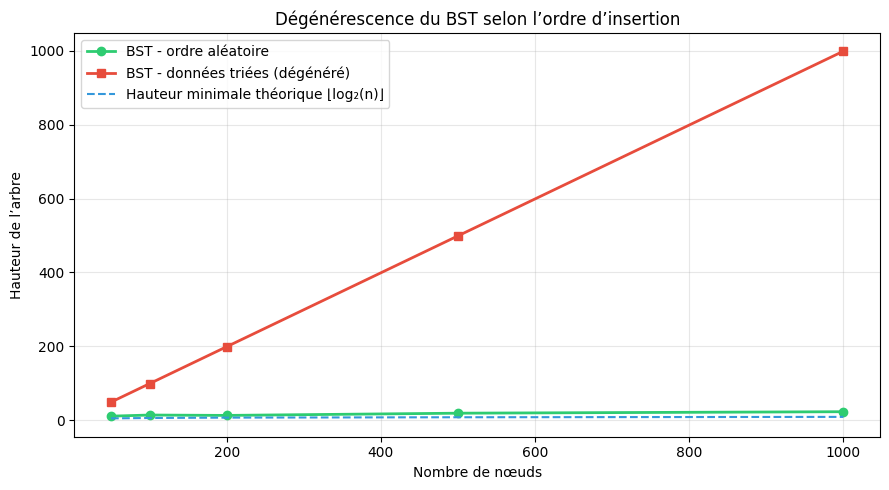


Pour n=1000 :
  BST aléatoire  : hauteur ≈ 23
  BST trié       : hauteur  = 999  (= n-1)
  Optimal        : hauteur  = 9  (= log₂n)


In [6]:
import random
import matplotlib.pyplot as plt

def build_bst(values: list) -> BST:
    bst = BST()
    for v in values:
        bst.insert(v)
    return bst

sizes = [50, 100, 200, 500, 1_000]
heights_random = []
heights_sorted = []
log2_heights   = []

import math
for n in sizes:
    values = list(range(n))

    # BST sur données aléatoires
    random.shuffle(values)
    heights_random.append(build_bst(values).height())

    # BST sur données triées (cas dégénéré)
    heights_sorted.append(build_bst(sorted(values)).height())

    # Hauteur théorique minimale
    log2_heights.append(math.floor(math.log2(n)))


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, heights_random, 'o-', color='#2ecc71', linewidth=2,
        label='BST - ordre aléatoire')
ax.plot(sizes, heights_sorted, 's-', color='#e74c3c', linewidth=2,
        label='BST - données triées (dégénéré)')
ax.plot(sizes, log2_heights,   '--', color='#3498db', linewidth=1.5,
        label='Hauteur minimale théorique ⌊log₂(n)⌋')

ax.set_xlabel('Nombre de nœuds')
ax.set_ylabel('Hauteur de l’arbre')
ax.set_title('Dégénérescence du BST selon l’ordre d’insertion')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPour n=1000 :")
print(f"  BST aléatoire  : hauteur ≈ {heights_random[-1]}")
print(f"  BST trié       : hauteur  = {heights_sorted[-1]}  (= n-1)")
print(f"  Optimal        : hauteur  = {log2_heights[-1]}  (= log₂n)")


## 5.2 BST → Arbre de décision CART

Un **arbre de décision CART** (Classification and Regression Trees) est lui aussi un arbre binaire, mais son rôle est différent : au lieu d'indexer des données, il **apprend une fonction de prédiction**.

La structure est la même : chaque nœud interne pose une question binaire (`feature <= seuil ?`), l'enfant gauche correspond à la réponse *oui*, l'enfant droit à *non*. Les feuilles contiennent la prédiction (classe majoritaire ou valeur moyenne).

```
         age <= 30 ?
        /            \
    oui               non
   /                     \
revenu <= 50k ?        revenu <= 80k ?
  /       \              /          \
 oui      non          oui          non
[Refus]  [Accord]   [Accord]      [Refus]
```

Le lien avec le BST est conceptuel mais fondamental :

| BST | Arbre de décision CART |
|---|---|
| Propriété : gauche < racine ≤ droite | Règle : gauche = condition vraie, droite = fausse |
| Construit par insertions successives | Construit par splits récursifs qui minimisent l'impureté (Gini) |
| Recherche en O(log n) | Prédiction en O(profondeur) |
| Dégénère si données triées | Surapprentit si profondeur non bornée |
| Rééquilibrage → AVL/Rouge-Noir | Régularisation → `max_depth`, `min_samples_split` |

La **profondeur** joue dans les deux cas le même rôle : plus l'arbre est profond, plus il est expressif et plus il risque d'être inadapté (BST dégénéré en liste, CART qui mémorise le bruit d'entraînement).

> L'implémentation CART from scratch et les benchmarks de surapprentissage constituent le cœur du mini-mémoire sujet 10.


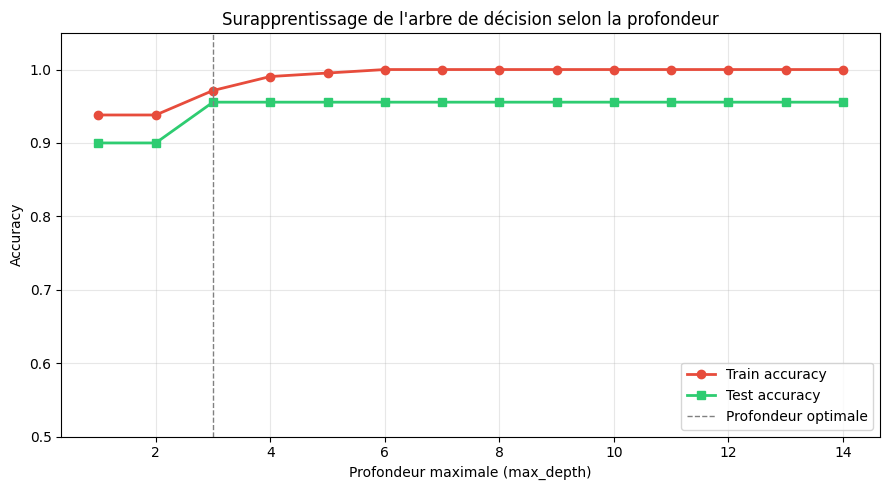

Profondeur optimale : 3
Train accuracy      : 0.971
Test  accuracy      : 0.956

A max_depth=14 (sans limite) :
  Train : 1.000  (mémorise le bruit)
  Test  : 0.956


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Dataset synthétique : 2 features pour visualisation
X, y = make_classification(
    n_samples=300, n_features=2, n_informative=2,
    n_redundant=0, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Impact de max_depth sur train/test accuracy
depths      = range(1, 15)
train_scores = []
test_scores  = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test,  y_test))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_scores, 'o-', color='#e74c3c', linewidth=2, label='Train accuracy')
ax.plot(depths, test_scores,  's-', color='#2ecc71', linewidth=2, label='Test accuracy')
ax.axvline(x=test_scores.index(max(test_scores)) + 1,
           color='gray', linestyle='--', linewidth=1, label='Profondeur optimale')
ax.set_xlabel('Profondeur maximale (max_depth)')
ax.set_ylabel('Accuracy')
ax.set_title('Surapprentissage de l\'arbre de décision selon la profondeur')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

best_depth = test_scores.index(max(test_scores)) + 1
print(f"Profondeur optimale : {best_depth}")
print(f"Train accuracy      : {train_scores[best_depth-1]:.3f}")
print(f"Test  accuracy      : {test_scores[best_depth-1]:.3f}")
print(f"\nA max_depth=14 (sans limite) :")
print(f"  Train : {train_scores[-1]:.3f}  (mémorise le bruit)")
print(f"  Test  : {test_scores[-1]:.3f}")


# PARTIE 5 : Liens avec l'ingénierie de données et le ML

## 5.1 BST → Index B-tree PostgreSQL

Quand on crée un index dans PostgreSQL avec `CREATE INDEX`, le moteur construit par défaut un **B-tree**, non pas un BST, mais sa généralisation à m enfants par nœud.

La différence fondamentale : dans un BST, chaque nœud porte une valeur et a exactement 0, 1 ou 2 enfants. Dans un B-tree, chaque nœud porte **plusieurs valeurs** (typiquement des dizaines à des centaines) et peut avoir autant d'enfants que de valeurs + 1. Un nœud de B-tree correspond à une **page disque** (typiquement 8 Ko dans PostgreSQL), ainsi regrouper beaucoup de valeurs par nœud minimise le nombre d'accès disque, qui sont coûteux.

La variante utilisée en pratique est le **B+ tree** : les données sont stockées **uniquement dans les feuilles**, les nœuds internes ne contenant que des clés de routage. Les feuilles sont **chaînées entre elles**, ce qui permet les parcours de plages (`BETWEEN`, `ORDER BY`) en suivant simplement les pointeurs sans remonter dans l'arbre.

```
               [30 | 70]                    ← nœud interne (routage)
              /     |     \
        [10|20]  [40|60]  [80|90]           ← feuilles (données)
            ↔        ↔        ↔             ← chaînage des feuilles
```

La propriété fondamentale est la même que pour le BST : la hauteur reste en O(log n), et avec un ordre m élevé (100-200 en base de données) cette hauteur est très faible même sur des millions de lignes. 3 à 4 niveaux suffisent pour indexer des centaines de millions de lignes.

### Ce que cela change concrètement

```sql
-- Sans index : PostgreSQL parcourt toutes les lignes (Seq Scan) → O(n)
SELECT * FROM transactions WHERE client_id = 42;

-- Avec index B-tree : PostgreSQL descend l'arbre (Index Scan) → O(log n)
CREATE INDEX idx_client ON transactions(client_id);
SELECT * FROM transactions WHERE client_id = 42;
```

La commande `EXPLAIN ANALYZE` permet de voir le plan choisi par PostgreSQL et de vérifier que l'index est bien utilisé. Le mini-mémoire sujet 2 approfondit ce point avec des benchmarks réels.


# Conclusion

## Réflexe à développer

> La hauteur d'un arbre est le paramètre critique. Sur un BST : vérifier si les données risquent d'être insérées dans un ordre pathologique. Sur un CART : `max_depth` est l'hyperparamètre de régularisation le plus important.

## Pour aller plus loin : Mini-mémoire

*Ces éléments ne sont pas traités dans ce notebook. Ils constituent des pistes d'approfondissement pour les étudiants qui travaillent sur un mini-mémoire en lien avec cette séance.*

- **Sujet 2 : Index BDD et B-tree** : implémentation AVL with rotations, structure détaillée du B-tree (split de nœud, optimisation disque), benchmarks PostgreSQL EXPLAIN ANALYZE avec et sans index sur 1M de lignes
- **Sujet 3 : Tries et auto-complétion** : le Trie est un arbre où chaque arête représente un caractère. Recherche en O(L) indépendamment du nombre de mots, application à l'auto-complétion avec tolérance aux fautes (Levenshtein)
- **Sujet 10 : Gradient Boosting** : implémentation CART from scratch (critère de Gini, splits récursifs), comparaison avec scikit-learn, courbe de convergence train/test vs nombre d'arbres
